# Рабочая тетрадь по ПСИИ №6

## Выполнил: студент группы БФБО-06-24 Петров Артем

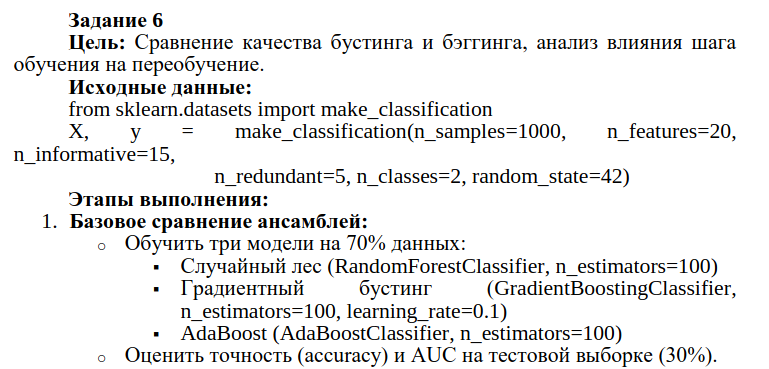

In [10]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.inspection import DecisionBoundaryDisplay

# Создание датасета и разделение на выборки:
X, y = make_classification(n_samples = 1000, n_features = 20, n_informative = 15, n_redundant = 5, n_classes = 2, random_state = 42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# Создание и обучение моделей:
rand_forest = RandomForestClassifier(n_estimators = 100)
grad_boost = GradientBoostingClassifier(learning_rate = 0.1, n_estimators = 100)
ada_boost = AdaBoostClassifier(n_estimators = 100)

rand_forest.fit(X_train, y_train)
grad_boost.fit(X_train, y_train)
ada_boost.fit(X_train, y_train)

# Создание предсказаний и вывод оценок точности моделей:
rf_pred_y = rand_forest.predict(X_test)
gb_pred_y = grad_boost.predict(X_test)
ab_pred_y = ada_boost.predict(X_test)

print(f'Оценка точности моделей:\n\nRandomForestClassifier: \naccuracy = {accuracy_score(rf_pred_y, y_test)}; \nAUC = {roc_auc_score(rf_pred_y, y_test)};\n')
print(f'GradientBoostingClassifier: \naccuracy = {accuracy_score(gb_pred_y, y_test)}; \nAUC = {roc_auc_score(gb_pred_y, y_test)};\n\nAdaBoostClassifier: \naccuracy = {accuracy_score(ab_pred_y, y_test)}; \nAUC = {roc_auc_score(ab_pred_y, y_test)}.')

/home/astaer/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Оценка точности моделей:

RandomForestClassifier: 
accuracy = 0.89; 
AUC = 0.8897951020045336;

GradientBoostingClassifier: 
accuracy = 0.8866666666666667; 
AUC = 0.8862908961593172;

AdaBoostClassifier: 
accuracy = 0.85; 
AUC = 0.8497933241477399.


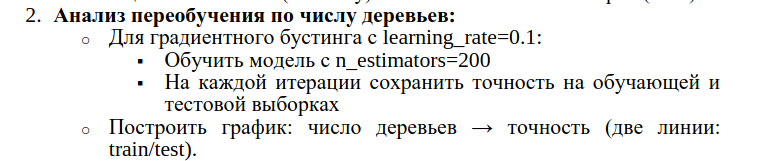

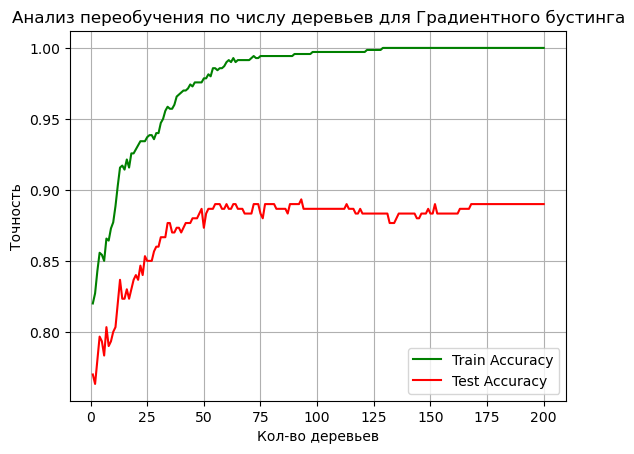

In [3]:
import matplotlib.pyplot as plt

# Создание и обучение модели:
gb_200 = GradientBoostingClassifier(n_estimators = 200, learning_rate = 0.1)
gb_200.fit(X_train, y_train)

# Создание списков для сохранения точности на каждой итерации:
train_acc_list = []
test_acc_list = []

# Сохранение и подсчёт точности по числу деревьев для модели
for train_pred_y, test_pred_y in zip(gb_200.staged_predict(X_train), gb_200.staged_predict(X_test)):
    train_acc_list.append(accuracy_score(y_train, train_pred_y))
    test_acc_list.append(accuracy_score(y_test, test_pred_y))

# Создание и вывод графика:
plt.plot(range(1, 201), train_acc_list, label = 'Train Accuracy', color = 'green')
plt.plot(range(1, 201), test_acc_list, label = 'Test Accuracy', color = 'red')
plt.xlabel('Кол-во деревьев')
plt.ylabel('Точность')
plt.title('Анализ переобучения по числу деревьев для Градиентного бустинга')
plt.legend()
plt.grid()
plt.show()

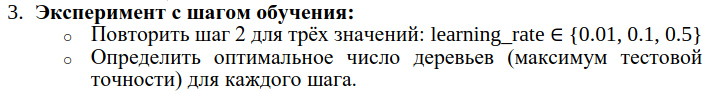

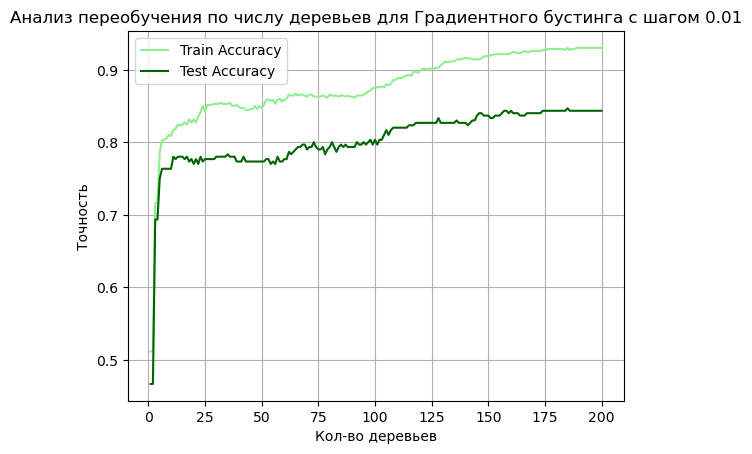

In [5]:
# создание и обучение моделей:
gb_lr001 = GradientBoostingClassifier(n_estimators = 200, learning_rate = 0.01)
gb_lr05 = GradientBoostingClassifier(n_estimators = 200, learning_rate = 0.5)
gb_lr001.fit(X_train, y_train)
gb_lr05.fit(X_train, y_train)

# Создание списков для фиксации значений
train_acc_list001, train_acc_list05 = [], []
test_acc_list001, test_acc_list05 = [], []

# Сохранение и подсчёт точности для моделей:
for train_pred001, test_pred001 in zip(gb_lr001.staged_predict(X_train), gb_lr001.staged_predict(X_test)):
    train_acc_list001.append(accuracy_score(y_train, train_pred001))
    test_acc_list001.append(accuracy_score(y_test, test_pred001))

for train_pred05, test_pred05 in zip(gb_lr05.staged_predict(X_train), gb_lr05.staged_predict(X_test)):
    train_acc_list05.append(accuracy_score(y_train, train_pred05))
    test_acc_list05.append(accuracy_score(y_test, test_pred05))

# Создание графиков:
# Вывод графика с шагом = 0.01
plt.plot(range(1, 201), train_acc_list001, label = 'Train Accuracy', color = 'lightgreen')
plt.plot(range(1, 201), test_acc_list001, label = 'Test Accuracy', color = 'darkgreen')
plt.xlabel('Кол-во деревьев')
plt.ylabel('Точность')
plt.title('Анализ переобучения по числу деревьев для Градиентного бустинга с шагом 0.01')
plt.legend()
plt.grid()
plt.show()

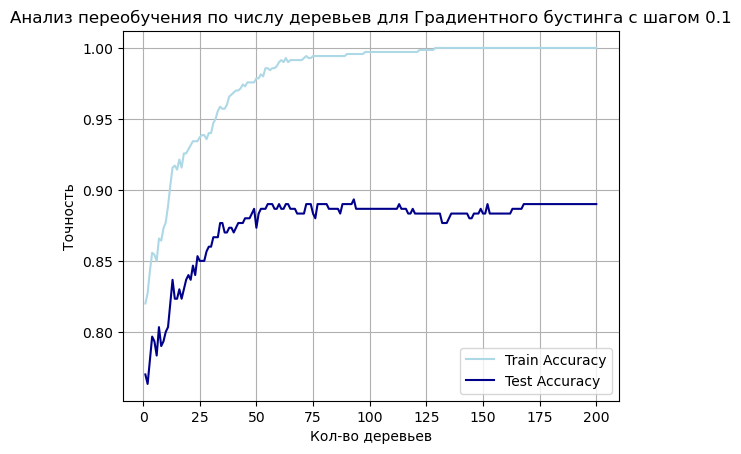

In [6]:
# повторный вывод графика с шагом = 0.1
plt.plot(range(1, 201), train_acc_list, label = 'Train Accuracy', color = 'lightblue')
plt.plot(range(1, 201), test_acc_list, label = 'Test Accuracy', color = 'darkblue')
plt.xlabel('Кол-во деревьев')
plt.ylabel('Точность')
plt.title('Анализ переобучения по числу деревьев для Градиентного бустинга с шагом 0.1')
plt.legend()
plt.grid()
plt.show()

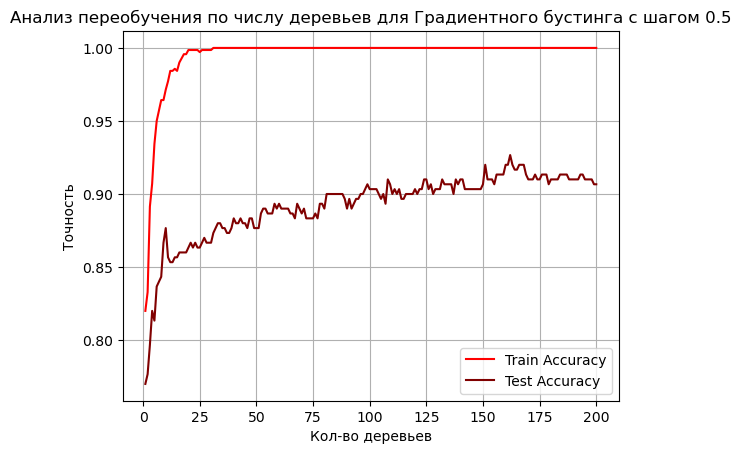

In [8]:
# Вывод графика с шагом = 0.5
plt.plot(range(1, 201), train_acc_list05, label = 'Train Accuracy', color = 'red')
plt.plot(range(1, 201), test_acc_list05, label = 'Test Accuracy', color = 'maroon')
plt.xlabel('Кол-во деревьев')
plt.ylabel('Точность')
plt.title('Анализ переобучения по числу деревьев для Градиентного бустинга с шагом 0.5')
plt.legend()
plt.grid()
plt.show()

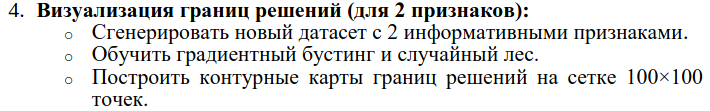

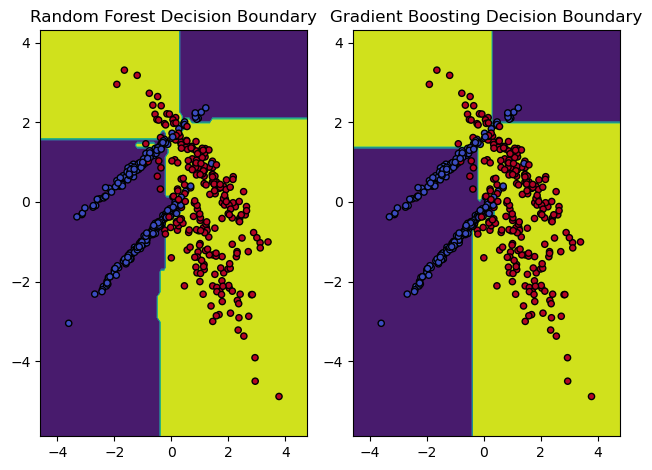

In [16]:
X2, y2 = make_classification(n_samples = 500, n_features = 2, n_informative = 2, n_redundant = 0, n_classes = 2, random_state = 42)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size = 0.3, random_state = 42)

# Создание и обучение моделей:
rand_forest2 = RandomForestClassifier(n_estimators = 100)
grad_boost2 = GradientBoostingClassifier(learning_rate = 0.1, n_estimators = 100)

# Обучение моделей:
rand_forest2.fit(X2_train, y2_train)
grad_boost2.fit(X2_train, y2_train)

# Визуализация графиков
fig, axes = plt.subplots(1, 2)
DecisionBoundaryDisplay.from_estimator(rand_forest2, X2, response_method = 'predict', ax = axes[0])
axes[0].scatter(X2[:, 0], X2[:, 1], c = y2, edgecolor = 'k', cmap = 'coolwarm', s = 20)
axes[0].set_title('Random Forest Decision Boundary')

DecisionBoundaryDisplay.from_estimator(grad_boost2, X2, response_method = 'predict', ax = axes[1])
axes[1].scatter(X2[:, 0], X2[:, 1], c = y2, edgecolor = 'k', cmap = 'coolwarm', s = 20)
axes[1].set_title('Gradient Boosting Decision Boundary')

plt.tight_layout()
plt.show()

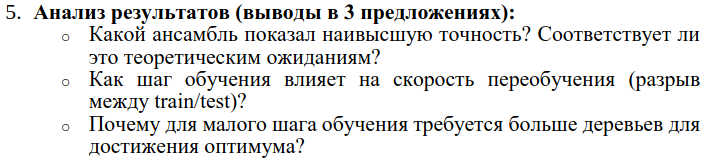

## Какой ансамбль показал наивысшую точность? Соответствует ли это теоретическим ожиданиям?

В данном эксперименте "Gradient Boosting" показал наивысшую точность и AUC. Это соответствует теоретическим ожиданиям, так как бустинг последовательно исправляет ошибки предыдущих моделей, что позволяет достичь более высокой точности на сложных данных

## Как шаг обучения влияет на скорость переобучения (разрыв между train/test)?

Чем выше шаг обучения, тем быстрее растёт точность на обучающей выборке, но тем раньше и сильнее проявляется переобучение. Низкий шаг замедляет и процесс обучения и переобучения модели.

## Почему для малого шага обучения требуется больше деревьев для достижения оптимума?

При маленьком шаге обучения каждое новое дерево вносит лишь небольшое изменение в итоговую модель. Чтобы накопить достаточную сложность и "дойти" до оптимальной точки на тестовых данных, требуется значительно больше последовательных шагов (деревьев), чем при высоком значении шага.